In [5]:
from NFWdist import *
import matplotlib.pyplot as plt

In [42]:
ngal = 200

In [17]:
con = 4


(array([13., 24., 26., 22., 24., 22., 18., 16., 19., 16.]),
 array([0.01509874, 0.11292971, 0.21076068, 0.30859165, 0.40642262,
        0.50425359, 0.60208457, 0.69991554, 0.79774651, 0.89557748,
        0.99340845]),
 <BarContainer object of 10 artists>)

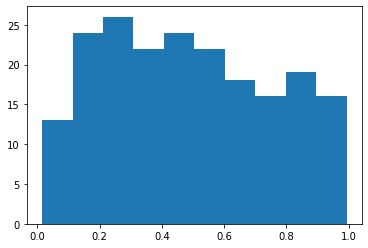

In [18]:
plt.hist(r)

In [35]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [47]:
r_list = []
for i in range(10):
    r = rnfw(ngal,con=con)
    r_list.append(r)

In [ ]:
rvir = 500

In [58]:
bin_edges = np.logspace(0, 4, 20)
bin_volumes = (4/3) * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)

#counts_sfr_av += counts_sfr*groupSFR
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def compute_prof(r_list):
    sfr_profile_normed_list = []
    for r in r_list:
        counts_sfr, _ = np.histogram(r*rvir, bins=bin_edges)
        sfr_profile = (counts_sfr) / bin_volumes
        sfr_profile_normed = sfr_profile/ngal

        sfr_profile_normed_list.append(sfr_profile_normed)

    return sfr_profile_normed_list

In [59]:
sfr_profile_normed_list = compute_prof(r_list)

[]

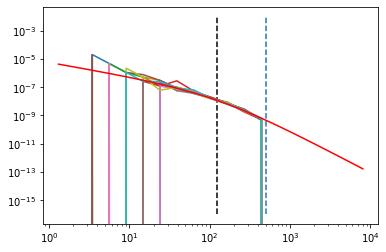

In [60]:
for i in range(10):
    plt.plot(bin_centers, sfr_profile_normed_list[i])

plt.plot(bin_centers, nfw_profile(bin_centers, rho0, r_s)/10**13.05, label="NFW (c=4,rvir=0.55)", c="red")
ymin = 10**-16
ymax = 10**-2
plt.vlines(rvir, ymin, ymax, label="rvir", linestyle="dashed")
plt.vlines(r_s, ymin, ymax, label="$r_s$", linestyle="dashed", color="k")
plt.loglog()

In [44]:
rvir = 500
print(rvir)
#rvir=1300
c = 4
r_s = rvir/c
print(r_s)
rho0 = rho_s(10**13, r_s, c)
print(rho0)

500
125.0
503357.5127337802


[]

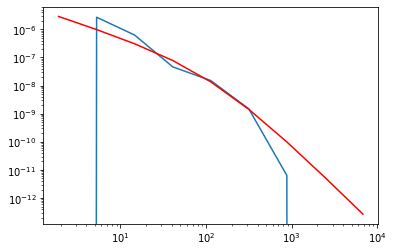

In [46]:
plt.plot(bin_centers, sfr_profile_normed)
plt.plot(bin_centers, nfw_profile(bin_centers, rho0, r_s)/10**13.05, label="NFW (c=4,rvir=0.55)", c="red")

plt.loglog()